In [59]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

<h1>Euler method</h1>

In [60]:
def solve_sir_euler(beta, gamma, S0, I0, R0, days, dt):
    # Calculate the total number of discrete time steps
    num_steps = int(days / dt)
    
    # Initialize arrays to store the population values at each time step
    S = np.zeros(num_steps)
    I = np.zeros(num_steps)
    R = np.zeros(num_steps)
    t = np.linspace(0, days, num_steps)
    
    # Set the initial conditions
    S[0] = S0
    I[0] = I0
    R[0] = R0
    N = S0 + I0 + R0 # Total population size
    
    # Forward Euler iteration loop
    for n in range(num_steps - 1):
        # 1. Calculate the current rates of change (the ODEs)
        dS = - (beta * S[n] * I[n]) / N
        dI = (beta * S[n] * I[n]) / N - (gamma * I[n])
        dR = gamma * I[n]
        
        # 2. Update the next value using the Euler formula: y_{n+1} = y_n + dt * f(t, y)
        S[n+1] = S[n] + dt * dS
        I[n+1] = I[n] + dt * dI
        R[n+1] = R[n] + dt * dR
        
    return t, S, I, R


In [61]:
def estimate_sir_parameters(file_path, training_days_count, N):
    # Reads data and estimates optimal beta and gamma using curve_fit.
    df = pd.read_csv(file_path)
    days_data = df['day'].values[:training_days_count]
    infected_data = df['infected'].values[:training_days_count]
    
    I0 = infected_data[0]
    S0 = N - I0
    R0 = 0
    
    # Internal function to run the Euler model for the optimizer
    def model_infected_wrapper(t, b, g):
        dt_fit = 0.1 
        max_day = t[-1] + 1 
        t_sim, _, I_sim, _ = solve_sir_euler(b, g, S0, I0, R0, max_day, dt_fit)
        return np.interp(t, t_sim, I_sim)

    # Optimize to find the best beta and gamma
    optimal_params, _ = curve_fit(
        model_infected_wrapper, 
        days_data, 
        infected_data, 
        bounds=(0, [3.0, 1.0]), 
        p0=[1.6, 0.4]
    )
    
    beta, gamma = optimal_params
    return beta, gamma, S0, I0, R0

In [62]:
def plot_sir_model(t, S, I, R, real_data=None, title=""):
    """
    Parameters:
        t (array-like): Array of time steps.
        S (array-like): Simulated susceptible population over time.
        I (array-like): Simulated infected population over time.
        R (array-like): Simulated recovered/removed population over time.
        real_data (tuple, optional): A tuple containing (real_t, real_I) arrays to overlay 
                                     observed data points. Defaults to None.
        title (str, optional): The title of the plot.
    """
    # Create the figure with specific dimensions
    plt.figure(figsize=(10, 6))
    
    # Plot the continuous Euler simulation curves
    plt.plot(t, S, label=r'Susceptible ($S$)', color='#1f77b4', linewidth=2.5)
    plt.plot(t, I, label=r'Infected ($I$)', color='#d62728', linewidth=2.5)
    plt.plot(t, R, label=r'Recovered ($R$)', color='#2ca02c', linewidth=2.5)
    
    # Optionally overlay real-world observed data points
    if real_data is not None:
        real_t, real_I = real_data
        plt.scatter(real_t, real_I, color='black', zorder=5, label='Observed Data ($I$)')
        
    # Formatting for academic presentation
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Time (Days)', fontsize=12)
    plt.ylabel('Population', fontsize=12)
    plt.legend(loc='best', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout() 
    
    # Display the plot window
    plt.show()

## Parameter Sensitivity Analysis

To fully understand the dynamics of the SIR model, it is necessary to examine how variations in the transmission rate ($\beta$) and the recovery rate ($\gamma$) influence the epidemic curve. The fundamental driver of this behavior is the basic reproduction number, defined as $R_0 = \frac{\beta}{\gamma}$. This ratio represents the expected number of secondary infections generated by a single infected individual in a fully susceptible population. 

As demonstrated in the first scenario below (varying $\beta$ while holding $\gamma$ constant), increasing the transmission rate leads to a significantly steeper exponential growth phase and a higher peak of infection. Conversely, artificially lowering $\beta$ simulates public health interventions such as social distancing, resulting in a delayed and much lower peak—a concept commonly referred to as "flattening the curve." 

In the second scenario (varying $\gamma$ while holding $\beta$ constant), the focus shifts to the duration of the infectious period. Increasing the recovery rate simulates the effects of improved medical treatments. A higher $\gamma$ causes individuals to transition into the recovered compartment more quickly, limiting their window to transmit the virus and drastically reducing the epidemic peak.

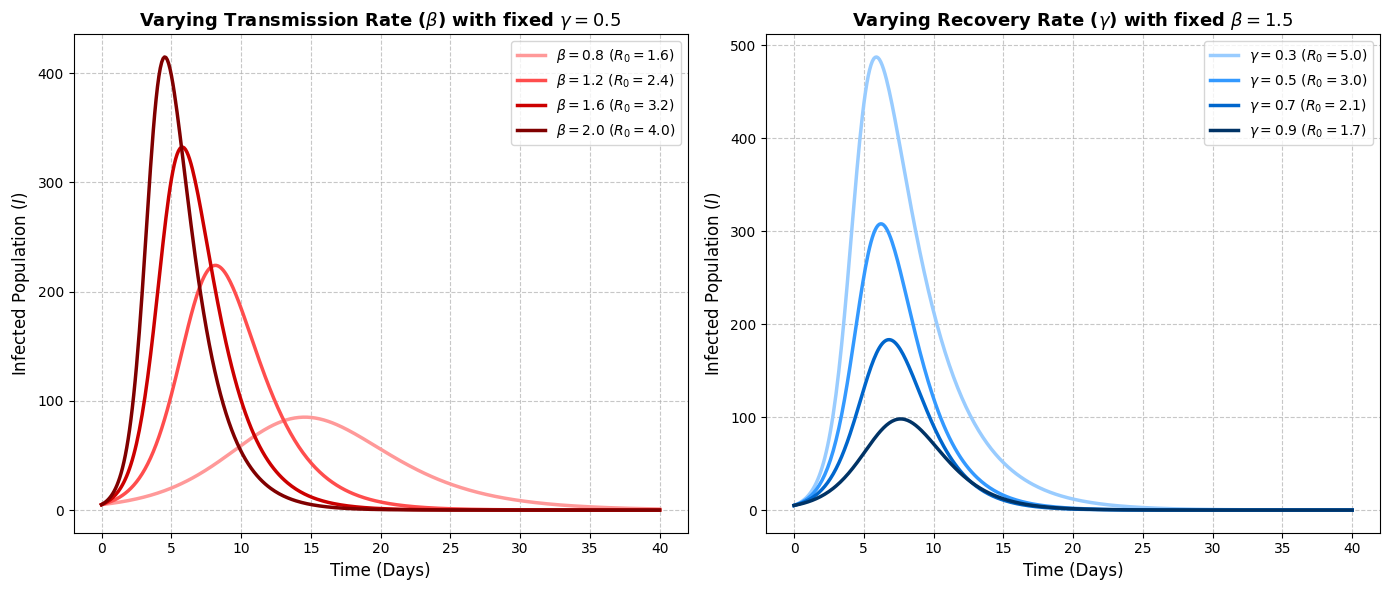

In [63]:
# --- Baseline Parameters ---
S0, I0, R0 = 995, 5, 0
days = 40
dt = 0.1

# Parameters to test
gamma_fixed = 0.5
betas_to_test = [0.8, 1.2, 1.6, 2.0]

beta_fixed = 1.5
gammas_to_test = [0.3, 0.5, 0.7, 0.9]

# --- Visualization Setup ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Varying Transmission Rate (Beta) ---
# Testing different beta values shows the impact of social distancing/quarantine
colors_beta = ['#ff9999', '#ff4d4d', '#cc0000', '#800000']
for i, b in enumerate(betas_to_test):
    t, S, I, R = solve_sir_euler(b, gamma_fixed, S0, I0, R0, days, dt)
    R0_val = b / gamma_fixed
    ax1.plot(t, I, label=rf'$\beta = {b}$ ($R_0 = {R0_val:.1f}$)', color=colors_beta[i], linewidth=2.5)

ax1.set_title(r'Varying Transmission Rate ($\beta$) with fixed $\gamma=0.5$', fontsize=13, fontweight='bold')
ax1.set_xlabel('Time (Days)', fontsize=12)
ax1.set_ylabel('Infected Population ($I$)', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Varying Recovery Rate (Gamma) ---
# Testing different gamma values shows the impact of medical treatments/faster recovery
colors_gamma = ['#99ccff', '#3399ff', '#0066cc', '#003366']
for i, g in enumerate(gammas_to_test):
    t, S, I, R = solve_sir_euler(beta_fixed, g, S0, I0, R0, days, dt)
    R0_val = beta_fixed / g
    ax2.plot(t, I, label=rf'$\gamma = {g}$ ($R_0 = {R0_val:.1f}$)', color=colors_gamma[i], linewidth=2.5)

ax2.set_title(r'Varying Recovery Rate ($\gamma$) with fixed $\beta=1.5$', fontsize=13, fontweight='bold')
ax2.set_xlabel('Time (Days)', fontsize=12)
ax2.set_ylabel('Infected Population ($I$)', fontsize=12)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

# Final formatting and save
plt.tight_layout()
plt.savefig('sir_parameter_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

Data-Driven Parameter Estimation

While theoretical curves are highly informative, a mathematical model must be grounded in reality. In this section, we apply the SIR model to real-world data: the 1978 influenza outbreak in a British boarding school. 

Instead of guessing the parameters, we use a computational optimization algorithm (`scipy.optimize.curve_fit`) to estimate the specific $\beta$ and $\gamma$ rates that best describe the early stages of this specific virus. To rigorously test our model's forecasting power, we implement a train-test split. We train the algorithm on only the first 7 days of the outbreak, and then run the simulation out to 14 days to see if the mathematics can accurately predict the end of the epidemic that it has not yet "seen."

Calculating parameters from data...
Calculated Beta: 1.8545
Calculated Gamma: 0.5046
Running Euler simulation...
Generating plot...


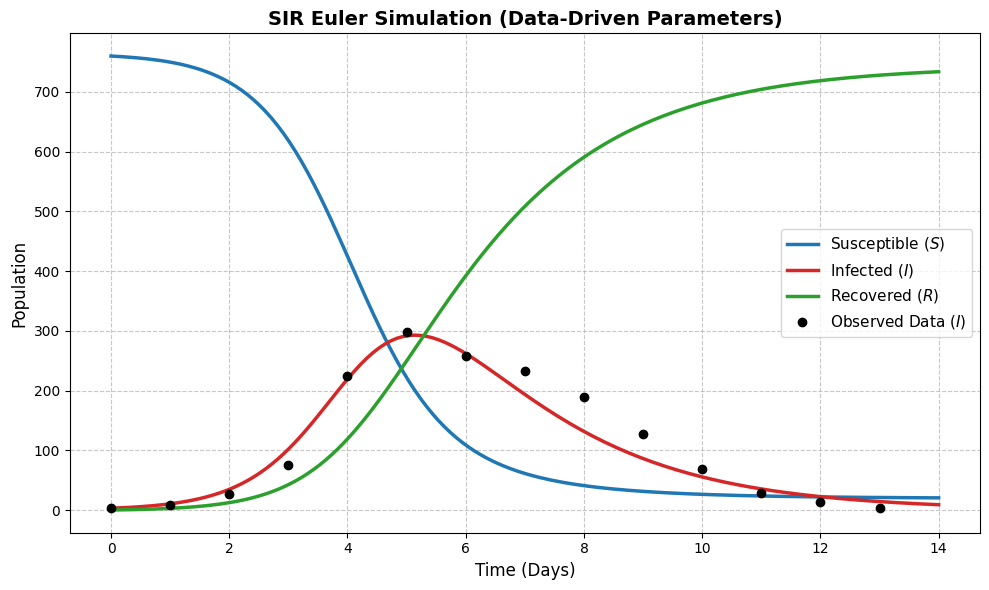

In [64]:
csv_file = 'Data/boarding_school_data.csv'
total_population = 763
days_to_train = 7
simulation_days = 14 
time_step = 0.1      

# Extract real data for the plot overlay
full_data = pd.read_csv(csv_file)
real_days = full_data['day'].values
real_infected = full_data['infected'].values

# B. Calculate parameters from data
print("Calculating parameters from data...")
calc_beta, calc_gamma, calc_S0, calc_I0, calc_R0 = estimate_sir_parameters(
    csv_file, days_to_train, total_population
)
print(f"Calculated Beta: {calc_beta:.4f}")
print(f"Calculated Gamma: {calc_gamma:.4f}")

# C. Call the solver using the CALCULATED parameters
print("Running Euler simulation...")
t, S, I, R = solve_sir_euler(
    beta=calc_beta, 
    gamma=calc_gamma, 
    S0=calc_S0, 
    I0=calc_I0, 
    R0=calc_R0, 
    days=simulation_days, 
    dt=time_step
)

# D. Plot the results
print("Generating plot...")
plot_sir_model(
    t, S, I, R, 
    real_data=(real_days, real_infected), 
    title="SIR Euler Simulation (Data-Driven Parameters)"
)